In [ ]:
#Establece la carpeta de trabajo al directorio raíz del proyecto
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from src.config import ConfigGlobal
from src.visualization import *
from src.statistics import *

config = ConfigGlobal()

In [13]:
# 1. Cargar los datos macro
# Ajusta la ruta si tu notebook no está en la raíz del proyecto
ruta_macro = "./data/raw/convergencia_hayek_01_macro.parquet"
df_macro = pd.read_parquet(ruta_macro)

# 2. Inspección básica de la estructura
print("--- ESTRUCTURA MACRO ---")
print(f"Dimensiones (Periodos, Cadenas): {df_macro.shape}")
display(df_macro.head()) # Muestra los primeros 5 periodos

--- ESTRUCTURA MACRO ---
Dimensiones (Periodos, Cadenas): (500, 3)


,Cadena_1,Cadena_2,Cadena_3
0,0.555307,1.420629,4.234129
1,0.562252,1.418168,4.230393
2,0.556601,1.412188,4.210895
3,0.562279,1.423413,4.131605
4,0.562252,1.418629,4.128008


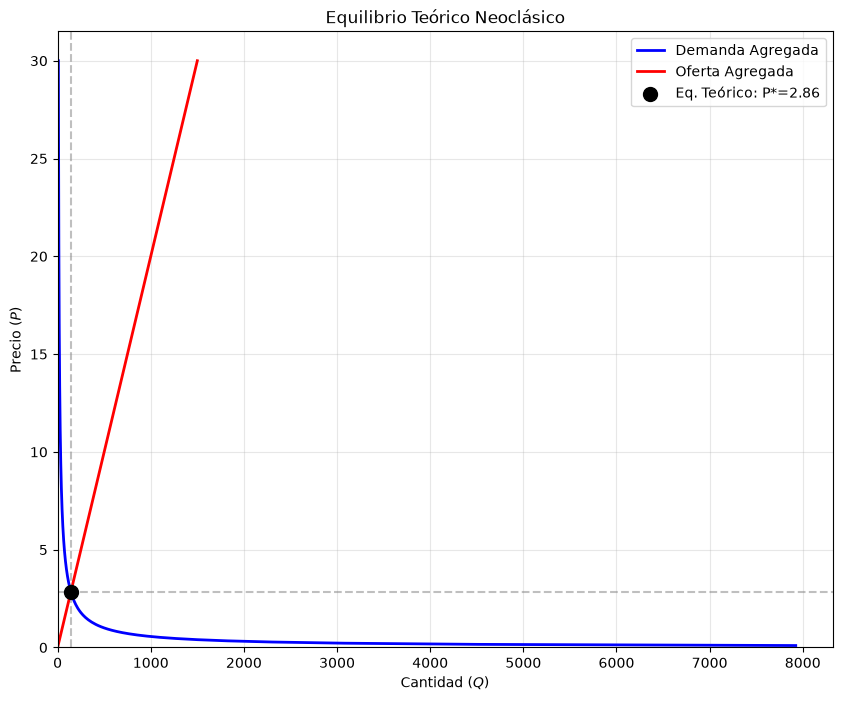

Precio de equilibrio (P): 2.856312625250501
Cantidad de equilibrio (Q): 142.81563126252505


In [22]:
ax = graficar_cruz_marshalliana(config)
plt.show()

P, Q = calcular_equilibrio_marshalliano(config)
print(f"Precio de equilibrio (P): {P}")
print(f"Cantidad de equilibrio (Q): {Q}")

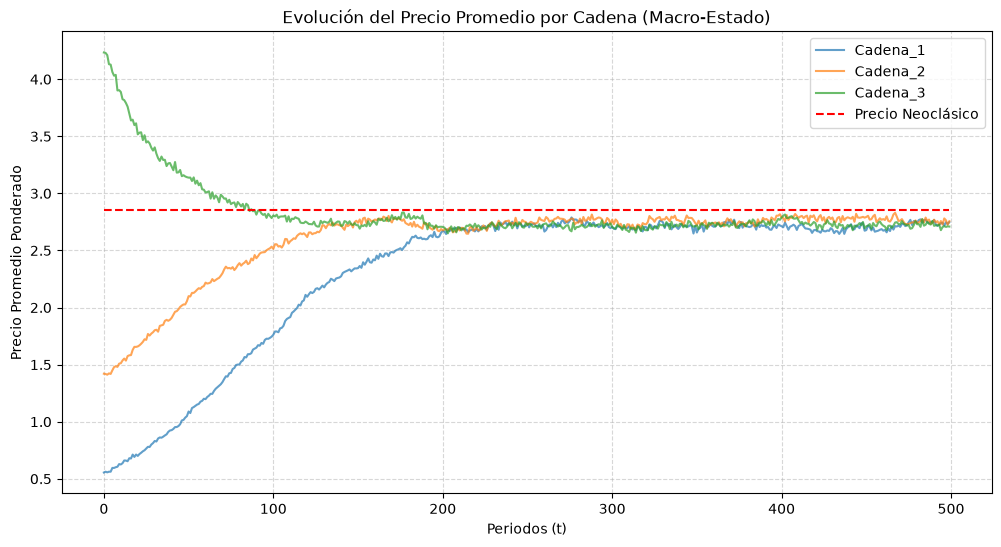

In [23]:
# 3. Visualización de la convergencia
# Graficamos todas las columnas (cadenas) a lo largo del índice (periodos)
ax = df_macro.plot(
    figsize=(12, 6), 
    alpha=0.7, 
    linewidth=1.5,
    title="Evolución del Precio Promedio por Cadena (Macro-Estado)"
)

ax.hlines(y = P, xmin = df_macro.index.min(), xmax = df_macro.index.max(), colors='red', linestyles='--', label='Precio Neoclásico')
ax.set_xlabel("Periodos (t)")
ax.set_ylabel("Precio Promedio Ponderado")
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.show()